# Data Understanding

In [1]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_excel("DATASETFIX.xlsx")

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Sort time series
df = df.sort_values(['Ticker', 'Date'])

# Filter global period
start_date = "2020-01-29"
end_date   = "2025-12-26"

df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

df

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,BIRD.JK,2020-01-29,"2,430.00","2,430.00","2,340.00","2,360.00","1,878.91","1,630,100"
1,BIRD.JK,2020-01-30,"2,360.00","2,370.00","2,330.00","2,340.00","1,862.99","673,900"
2,BIRD.JK,2020-01-31,"2,340.00","2,420.00","2,270.00","2,350.00","1,870.95","722,400"
3,BIRD.JK,2020-02-03,"2,350.00","2,460.00","2,290.00","2,390.00","1,902.79","1,643,500"
4,BIRD.JK,2020-02-04,"2,390.00","2,510.00","2,390.00","2,460.00","1,958.52","1,811,000"
...,...,...,...,...,...,...,...,...
8557,TAXI.JK,2025-12-19,20.00,20.00,19.00,19.00,19.00,"29,034,300"
8558,TAXI.JK,2025-12-22,19.00,20.00,18.00,18.00,18.00,"58,112,200"
8559,TAXI.JK,2025-12-23,19.00,19.00,19.00,19.00,19.00,"37,918,800"
8560,TAXI.JK,2025-12-24,20.00,20.00,18.00,18.00,18.00,"90,033,800"


In [2]:
num = df['Ticker'].nunique()
print("There are {} companies in this dataset".format(num))

all_companies = df['Ticker'].unique()
print("\n",all_companies)

There are 6 companies in this dataset

 ['BIRD.JK' 'BPTR.JK' 'GIAA.JK' 'LRNA.JK' 'PURA.JK' 'TAXI.JK']


In [3]:
dataset_info = []

for ticker, group in df.groupby('Ticker'):
    dataset_info.append({
        "Dataset": ticker,
        "Total Attributes": group.shape[1] - 2,  # exclude Ticker & Date
        "Total Rows": len(group)
    })

table_31 = pd.DataFrame(dataset_info)
table_31

,Dataset,Total Attributes,Total Rows
0,BIRD.JK,6,1427
1,BPTR.JK,6,1427
2,GIAA.JK,6,1427
3,LRNA.JK,6,1427
4,PURA.JK,6,1427
5,TAXI.JK,6,1427


In [4]:
missing_info = []

for ticker, group in df.groupby('Ticker'):
    missing_info.append({
        "Dataset": ticker,
        "Total Missing Values": group.isnull().sum().sum(),
        "Total Rows": len(group)
    })

table_32 = pd.DataFrame(missing_info)
table_32

,Dataset,Total Missing Values,Total Rows
0,BIRD.JK,0,1427
1,BPTR.JK,0,1427
2,GIAA.JK,0,1427
3,LRNA.JK,0,1427
4,PURA.JK,0,1427
5,TAXI.JK,0,1427


# Data Preparation

In [5]:
price_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

for col in price_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

In [6]:
# ===============================
# Data Normalization (Min–Max)
# ===============================

from sklearn.preprocessing import MinMaxScaler

features = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

scaled_data = {}
scalers = {}

for ticker, group in df.groupby('Ticker'):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(group[features])

    scaled_data[ticker] = scaled
    scalers[ticker] = scaler

# Squeance

In [7]:
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i, 3])  # Close price
    return np.array(X), np.array(y)

WINDOW = 60
sequences = {}

for ticker in scaled_data:
    X, y = create_sequences(scaled_data[ticker], WINDOW)
    sequences[ticker] = (X, y)

# Spliting

In [8]:
train_test_data = {}

for ticker, (X, y) in sequences.items():
    split = int(len(X) * 0.8)
    train_test_data[ticker] = {
        'X_train': X[:split],
        'X_test' : X[split:],
        'y_train': y[:split],
        'y_test' : y[split:]
    }

for ticker, data in train_test_data.items():
    print(f"{ticker}")
    print(f"  Train samples : {data['X_train'].shape[0]}")
    print(f"  Test samples  : {data['X_test'].shape[0]}")
    print("-" * 30)

BIRD.JK
  Train samples : 1093
  Test samples  : 274
------------------------------
BPTR.JK
  Train samples : 1093
  Test samples  : 274
------------------------------
GIAA.JK
  Train samples : 1093
  Test samples  : 274
------------------------------
LRNA.JK
  Train samples : 1093
  Test samples  : 274
------------------------------
PURA.JK
  Train samples : 1093
  Test samples  : 274
------------------------------
TAXI.JK
  Train samples : 1093
  Test samples  : 274
------------------------------


#CNN+LSTM

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout

def build_cnn_lstm(input_shape, activation='relu', optimizer='adam'):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3,
                     activation=activation,
                     input_shape=input_shape))
    model.add(LSTM(50, activation=activation))
    model.add(Dense(1))

    model.compile(
        loss='mse',
        optimizer=optimizer
    )
    return model

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

results_all = []

for ticker, data in train_test_data.items():  # PAKAI GAN
    X_train = data['X_train']
    y_train = data['y_train']
    X_test  = data['X_test']
    y_test  = data['y_test']

    model = build_cnn_lstm(X_train.shape[1:], 'relu', 'adam')

    start = time.time()
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
    elapsed = (time.time() - start) / 60

    y_pred = model.predict(X_test)

    results_all.append([
        ticker,
        elapsed,
        mean_absolute_error(y_test, y_pred),
        np.mean(np.abs((y_test - y_pred.flatten()) / y_test)) * 100,
        mean_squared_error(y_test, y_pred),
        r2_score(y_test, y_pred),
        np.sqrt(mean_squared_error(y_test, y_pred))
    ])

table_41 = pd.DataFrame(
    results_all,
    columns=['Dataset','Elapsed Time (min)','MAE','MAPE','MSE','R-Squared','RMSE']
)
table_41

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


,Dataset,Elapsed Time (min),MAE,MAPE,MSE,R-Squared,RMSE
0,BIRD.JK,0.313586,0.018095,3.258978,0.000510,0.940755,0.022587
1,BPTR.JK,0.278153,0.005557,4.412538,0.000055,0.932529,0.007442
2,GIAA.JK,0.324130,0.007510,inf,0.000127,0.965608,0.011277
3,LRNA.JK,0.276895,0.026052,9.470308,0.001809,0.901341,0.042527
4,PURA.JK,0.289499,0.005559,11.841306,0.000058,0.963363,0.007626
5,TAXI.JK,0.282006,0.061919,28.383594,0.006158,0.537937,0.078474


In [11]:
# table_41['R-Squared'].mean() * 100

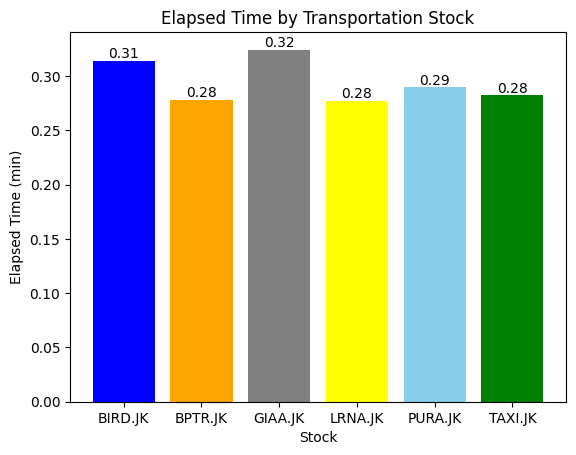

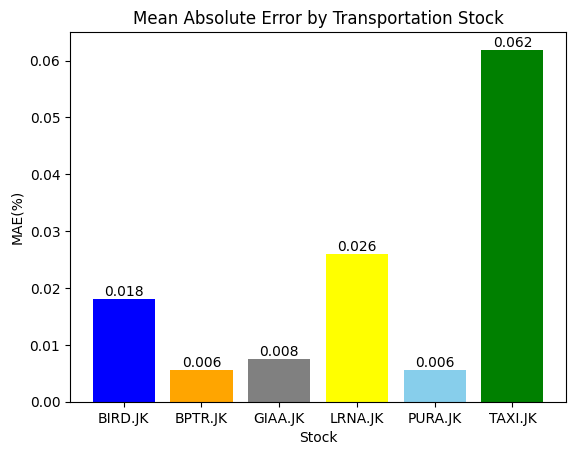

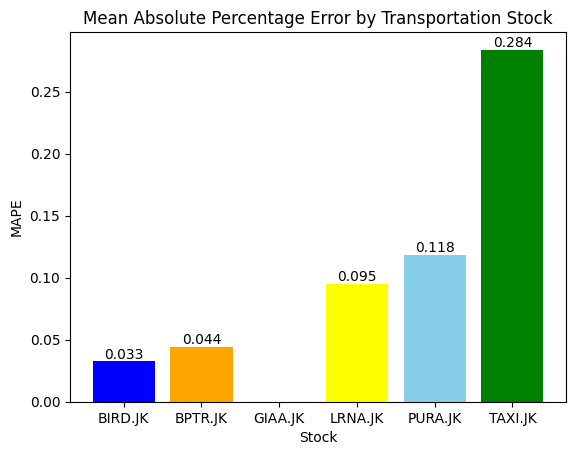

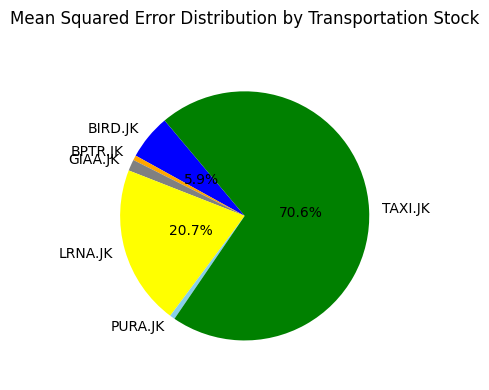

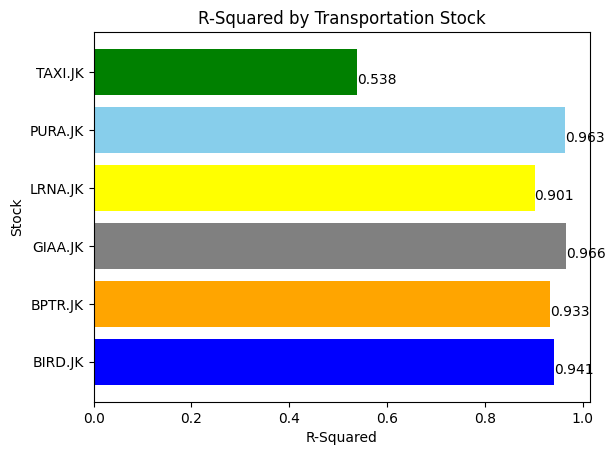

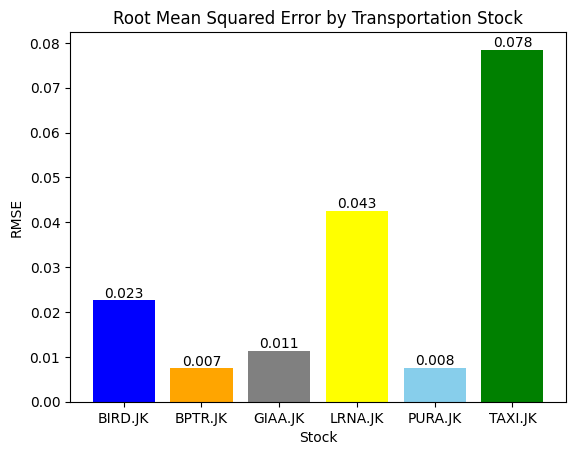

In [12]:
import matplotlib.pyplot as plt

# Pastikan table_41 sudah ada
df_plot = table_41.copy()

# Warna khusus tiap saham
colors = {
    'BIRD.JK': 'blue',
    'BPTR.JK': 'orange',
    'GIAA.JK': 'gray',
    'LRNA.JK': 'yellow',
    'PURA.JK': 'skyblue',
    'TAXI.JK': 'green'
}

#Elapsed Time by Transportation Stock (Bar Chart)

plt.figure()
bars = plt.bar(
    df_plot['Dataset'],
    df_plot['Elapsed Time (min)'],
    color=[colors[x] for x in df_plot['Dataset']]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center', va='bottom'
    )

plt.title('Elapsed Time by Transportation Stock')
plt.ylabel('Elapsed Time (min)')
plt.xlabel('Stock')
plt.show()

#Mean Absolute Error (MAE) by Transportation Stock

plt.figure()
bars = plt.bar(
    df_plot['Dataset'],
    df_plot['MAE'],
    color=[colors[x] for x in df_plot['Dataset']]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha='center', va='bottom'
    )

plt.title('Mean Absolute Error by Transportation Stock')
plt.ylabel('MAE(%)')
plt.xlabel('Stock')
plt.show()

#Mean Absolute Percentage Error (MAPE)

plt.figure()
bars = plt.bar(
    table_41['Dataset'],
    table_41['MAPE'] / 100,
    color=[colors[x] for x in table_41['Dataset']]
)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y,
             f"{y:.3f}", ha='center', va='bottom')

plt.title("Mean Absolute Percentage Error by Transportation Stock")
plt.ylabel("MAPE")
plt.xlabel("Stock")
plt.show()


#Mean Squared Error (MSE) – Pie Chart

plt.figure(figsize=(4, 4))  #  perbesar ukuran

plt.pie(
    df_plot['MSE'],
    labels=df_plot['Dataset'],
    autopct=lambda p: f'{p:.1f}%' if p > 5 else '',  # tampilkan % besar saja
    colors=[colors[x] for x in df_plot['Dataset']],
    startangle=130,
    pctdistance=0.45,
    labeldistance=1.1
)

plt.title('Mean Squared Error Distribution by Transportation Stock', pad=20)
plt.axis('equal')  # biar bulat sempurna
plt.tight_layout()
plt.show()


#R-Squared by Transportation Stock

plt.figure()
bars = plt.barh(
    table_41['Dataset'],
    table_41['R-Squared'],
    color=[colors[x] for x in table_41['Dataset']]
)

for bar in bars:
    x = bar.get_width()
    plt.text(x, bar.get_y() + bar.get_height()/3,
             f"{x:.3f}", va='center')

plt.title("R-Squared by Transportation Stock")
plt.xlabel("R-Squared")
plt.ylabel("Stock")
plt.show()

#Root Mean Squared Error (RMSE)

plt.figure()
bars = plt.bar(
    table_41['Dataset'],
    table_41['RMSE'],
    color=[colors[x] for x in table_41['Dataset']]
)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y,
             f"{y:.3f}", ha='center', va='bottom')

plt.title("Root Mean Squared Error by Transportation Stock")
plt.ylabel("RMSE")
plt.xlabel("Stock")
plt.show()

#eksperimen hyperparameter

In [13]:
activations = ['linear','relu','sigmoid','tanh']
optimizers  = ['adadelta','adagrad','adam','adamax','nadam','rmsprop','sgd']

selected_tickers = ['BIRD.JK','BPTR.JK','GIAA.JK','LRNA.JK','PURA.JK','TAXI.JK']
results_exp = []

In [14]:
for ticker in selected_tickers:
    data = train_test_data[ticker]

    for act in activations:
        for opt in optimizers:
            model = build_cnn_lstm(
                data['X_train'].shape[1:], act, opt
            )

            start = time.time()
            model.fit(data['X_train'], data['y_train'],
                      epochs=50, batch_size=32, verbose=0)
            elapsed = (time.time() - start) / 60

            y_pred = model.predict(data['X_test'])

            mae  = mean_absolute_error(data['y_test'], y_pred)
            mse  = mean_squared_error(data['y_test'], y_pred)
            rmse = np.sqrt(mse)
            mape = np.mean(np.abs(
                (data['y_test'] - y_pred.flatten()) / data['y_test']
            )) * 100
            r2   = r2_score(data['y_test'], y_pred)

            results_exp.append([
                ticker, act, opt, elapsed, mae, mape, mse, r2, rmse
            ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [15]:
columns = ['Dataset','Activation','Optimizer',
           'Elapsed Time (min)','MAE','MAPE','MSE','R-Squared','RMSE']

table_42 = pd.DataFrame(results_exp, columns=columns)
table_42

,Dataset,Activation,Optimizer,Elapsed Time (min),MAE,MAPE,MSE,R-Squared,RMSE
0,BIRD.JK,linear,adadelta,0.285470,0.045493,7.977713,0.003888,0.548515,0.062353
1,BIRD.JK,linear,adagrad,0.259489,0.030587,5.448381,0.001428,0.834226,0.037783
2,BIRD.JK,linear,adam,0.278469,0.015255,2.725606,0.000390,0.954737,0.019743
3,BIRD.JK,linear,adamax,0.271256,0.019068,3.442097,0.000567,0.934152,0.023812
4,BIRD.JK,linear,nadam,0.298613,0.012949,2.292462,0.000329,0.961772,0.018144
...,...,...,...,...,...,...,...,...,...
163,TAXI.JK,tanh,adam,0.234237,0.021078,9.797552,0.000953,0.928492,0.030871
164,TAXI.JK,tanh,adamax,0.224103,0.035838,18.911783,0.002177,0.836674,0.046656
165,TAXI.JK,tanh,nadam,0.246073,0.021118,9.920161,0.000945,0.929129,0.030733
166,TAXI.JK,tanh,rmsprop,0.204441,0.032485,18.327992,0.001959,0.853016,0.044260


In [16]:
file_path = "hasil_eksperimen_activation_optimizer.xlsx"

table_42.to_excel(file_path, index=False)

print(f"File berhasil disimpan: {file_path}")

File berhasil disimpan: hasil_eksperimen_activation_optimizer.xlsx


In [17]:
# Ambil model terbaik berdasarkan MAE terendah
best_models = (
    table_42
    .sort_values('MAE')
    .groupby('Dataset')
    .first()
    .reset_index()
)

best_models

,Dataset,Activation,Optimizer,Elapsed Time (min),MAE,MAPE,MSE,R-Squared,RMSE
0,BIRD.JK,linear,nadam,0.298613,0.012949,2.292462,0.000329,0.961772,0.018144
1,BPTR.JK,linear,adam,0.273477,0.004402,3.582478,0.000039,0.952556,0.006241
2,GIAA.JK,relu,nadam,0.286443,0.006546,inf,0.000106,0.971203,0.010319
3,LRNA.JK,tanh,adam,0.226880,0.021760,7.398932,0.001626,0.911273,0.040329
4,PURA.JK,linear,nadam,0.294959,0.004470,8.235505,0.000044,0.972540,0.006602
5,TAXI.JK,tanh,adam,0.234237,0.021078,9.797552,0.000953,0.928492,0.030871


In [18]:
from scipy.stats import shapiro

final_results = []
pred_store = {}
residual_store = {}

for _, row in best_models.iterrows():
    ticker = row['Dataset']
    act    = row['Activation']
    opt    = row['Optimizer']

    data = train_test_data[ticker]

    model = build_cnn_lstm(data['X_train'].shape[1:], act, opt)
    model.fit(data['X_train'], data['y_train'], epochs=50, batch_size=32, verbose=0)

    y_pred = model.predict(data['X_test']).flatten()
    y_true = data['y_test']
    residuals = y_true - y_pred

    stat, p = shapiro(residuals)

    pred_store[ticker] = y_pred
    residual_store[ticker] = residuals

    final_results.append([
        ticker, act, opt,
        row['MAE'], row['MAPE'], row['MSE'],
        row['R-Squared'], row['RMSE'],
        stat, p, residuals
    ])

columns = [
    'Dataset','Activation','Optimizer',
    'MAE','MAPE','MSE','R-Squared','RMSE',
    'T-Statistic','P-Value', 'Residuals'
]

table_45 = pd.DataFrame(final_results, columns=columns)
table_45['P-Value'] = (table_45['P-Value'] * 1e4).round(4)
table_45

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


,Dataset,Activation,Optimizer,MAE,MAPE,MSE,R-Squared,RMSE,T-Statistic,P-Value,Residuals
0,BIRD.JK,linear,nadam,0.012949,2.292462,0.000329,0.961772,0.018144,0.962656,0.0159,"[0.029608745288028926, 0.02144523199786419, 0...."
1,BPTR.JK,linear,adam,0.004402,3.582478,0.000039,0.952556,0.006241,0.941619,0.0001,"[-0.004392390451483097, 0.0011476185847039133,..."
2,GIAA.JK,relu,nadam,0.006546,inf,0.000106,0.971203,0.010319,0.804361,0.0000,"[-0.00883366410546478, -0.006314803012494805, ..."
3,LRNA.JK,tanh,adam,0.021760,7.398932,0.001626,0.911273,0.040329,0.689887,0.0000,"[-0.020705031519905215, -0.003955500489250308,..."
4,PURA.JK,linear,nadam,0.004470,8.235505,0.000044,0.972540,0.006602,0.891557,0.0000,"[0.0017577223479747772, 0.0024105794727802277,..."
5,TAXI.JK,tanh,adam,0.021078,9.797552,0.000953,0.928492,0.030871,0.867190,0.0000,"[0.012009413722826504, 0.012924061898066067, 0..."


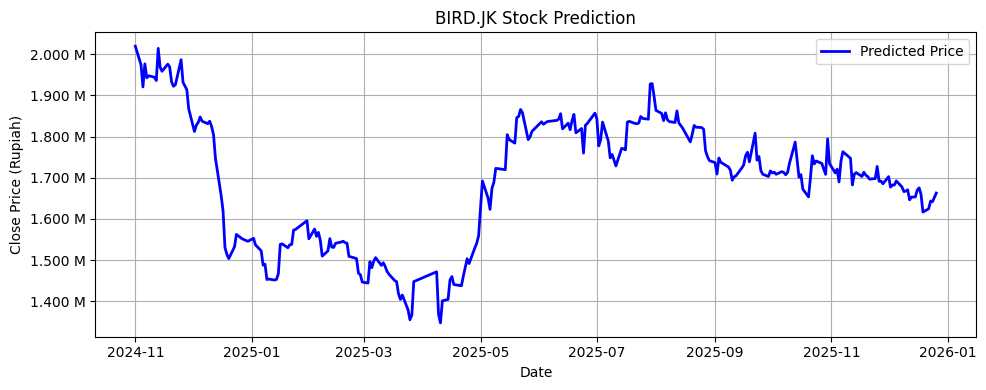

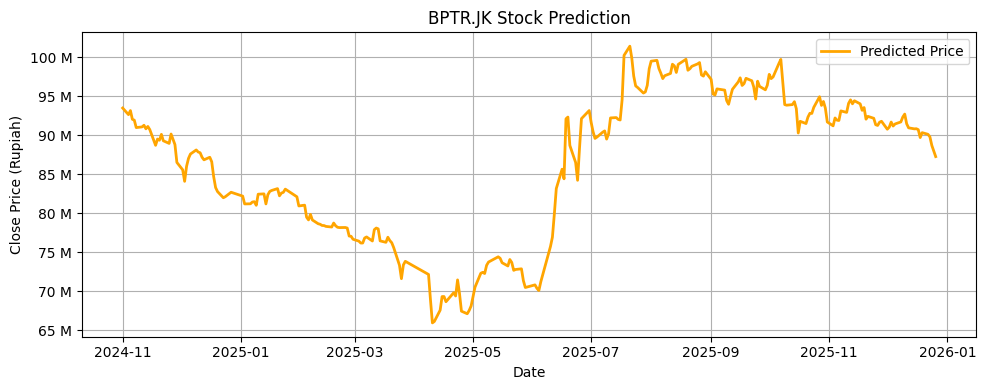

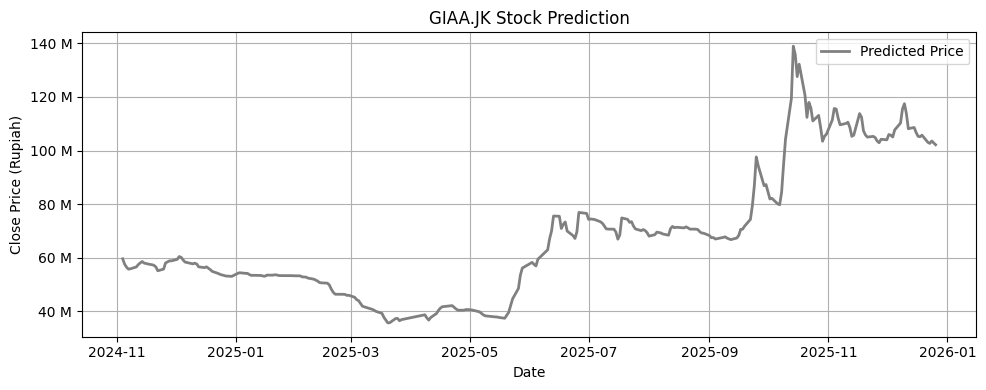

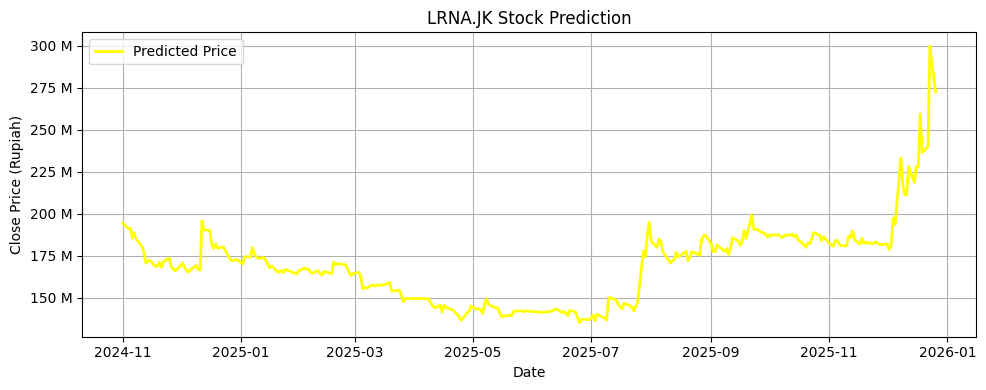

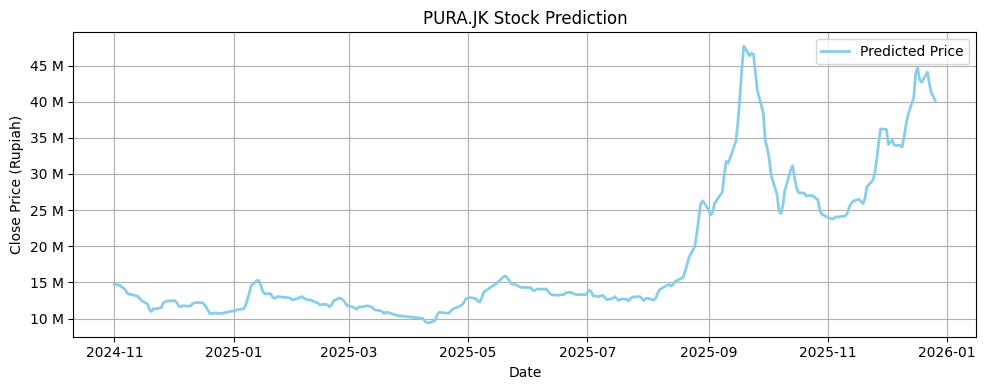

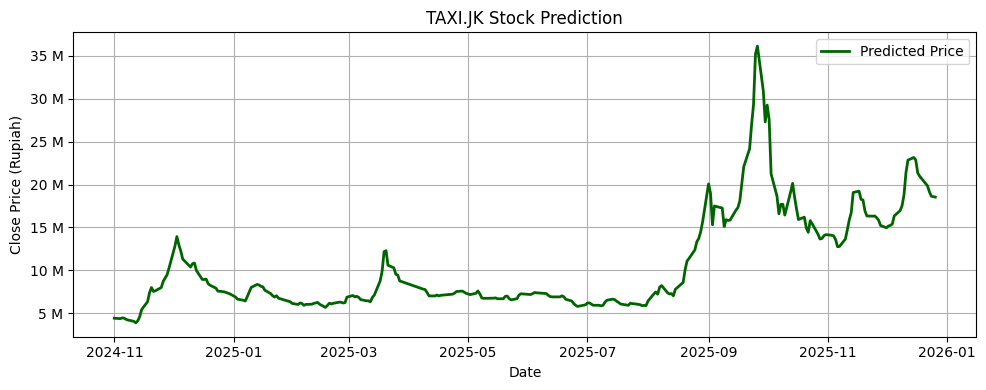

In [19]:
from matplotlib.ticker import FuncFormatter
import numpy as np
import matplotlib.pyplot as plt

color_map = {
    'BIRD.JK': 'blue',
    'BPTR.JK': 'orange',
    'GIAA.JK': 'gray',
    'LRNA.JK': 'yellow',
    'PURA.JK': 'skyblue',
    'TAXI.JK': 'darkgreen'
}

def rupiah_formatter_juta(x, pos):
    return f'{x/1000:.3f} M' if x >= 1000 else f'{x:.0f} M'

for _, row in best_models.iterrows():
    ticker = row['Dataset']
    y_pred = pred_store[ticker]

    scaler = scalers[ticker]
    dummy = np.zeros((len(y_pred), scaler.n_features_in_))
    dummy[:, 0] = y_pred
    y_pred = scaler.inverse_transform(dummy)[:, 0]

    dates = df[df['Ticker'] == ticker]['Date'].iloc[-len(y_pred):]

    plt.figure(figsize=(10,4))
    plt.plot(dates, y_pred, color=color_map[ticker], linewidth=2, label='Predicted Price')
    plt.title(f"{ticker} Stock Prediction")
    plt.xlabel("Date")
    plt.ylabel("Close Price (Rupiah)")
    plt.gca().yaxis.set_major_formatter(FuncFormatter(rupiah_formatter_juta))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

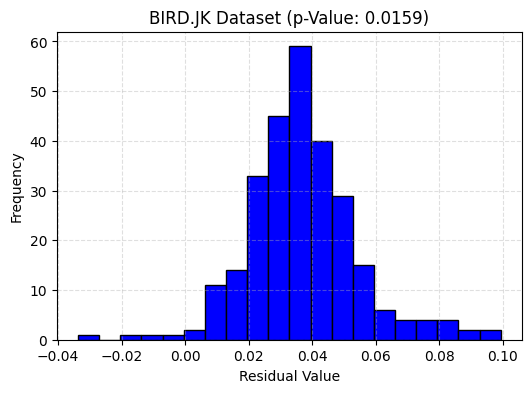

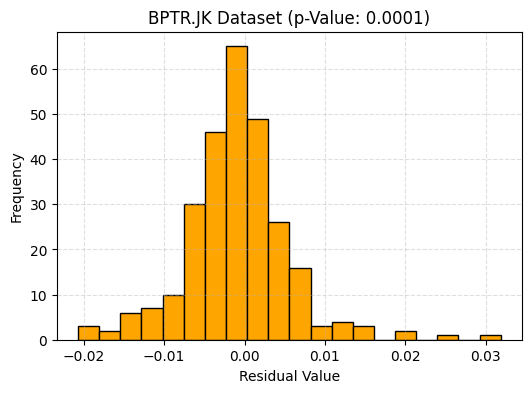

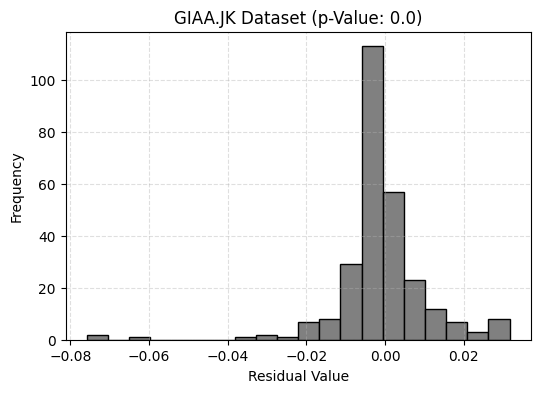

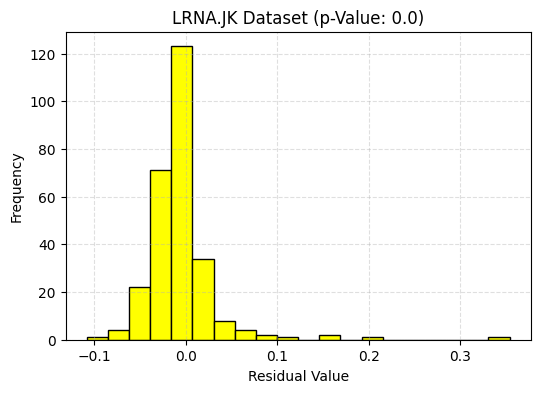

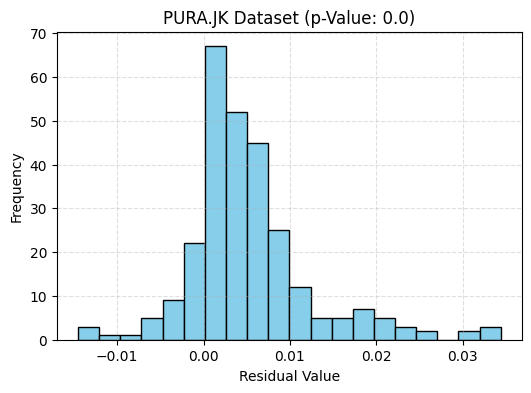

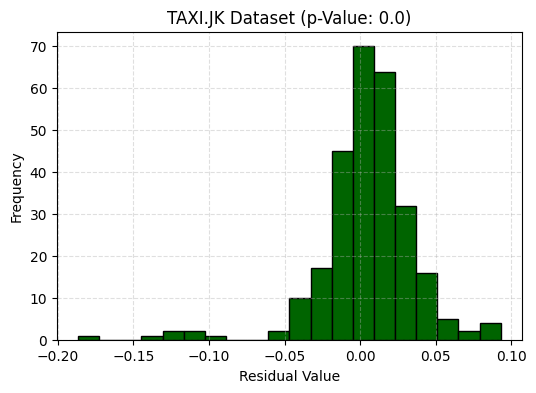

In [20]:
color_map = {
    'BIRD.JK': 'blue',
    'BPTR.JK': 'orange',
    'GIAA.JK': 'gray',
    'LRNA.JK': 'yellow',
    'PURA.JK': 'skyblue',
    'TAXI.JK': 'darkgreen'
}

for _, row in table_45.iterrows():
    ticker = row['Dataset']
    pval   = row['P-Value']
    residuals = row['Residuals']   # ← INI YANG PENTING

    plt.figure(figsize=(6,4))
    plt.hist(
        residuals,
        bins=20,
        color=color_map.get(ticker, 'blue'),
        edgecolor='black'
    )

    plt.title(f"{ticker} Dataset (p-Value: {pval})")
    plt.xlabel("Residual Value")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.4)

    plt.show()

In [ ]:
# ======================================
# Build Standalone LSTM Model
# ======================================

def build_lstm(input_shape, activation='relu', optimizer='adam'):
    from tensorflow.keras.layers import LSTM, Dense
    
    model = Sequential()
    model.add(LSTM(50, activation=activation, input_shape=input_shape))
    model.add(Dense(1))
    
    model.compile(
        loss='mse',
        optimizer=optimizer
    )
    return model

In [ ]:
# ======================================
# Train & Save CNN+LSTM and LSTM Models
# ======================================

import os

# Create folders untuk menyimpan model
os.makedirs("models/cnn_lstm", exist_ok=True)
os.makedirs("models/lstm", exist_ok=True)

# Dictionary untuk menyimpan model yang sudah dilatih
trained_models = {}
trained_lstm_models = {}

for _, row in best_models.iterrows():
    ticker = row['Dataset']
    act    = row['Activation']
    opt    = row['Optimizer']
    
    data = train_test_data[ticker]
    
    # ===== Train CNN+LSTM Model =====
    print(f"\n{'='*50}")
    print(f"Training CNN+LSTM Model for {ticker}")
    print(f"{'='*50}")
    
    cnn_lstm_model = build_cnn_lstm(data['X_train'].shape[1:], act, opt)
    cnn_lstm_model.fit(
        data['X_train'], data['y_train'], 
        epochs=50, batch_size=32, verbose=0
    )
    
    # Save CNN+LSTM Model
    cnn_lstm_path = f"models/cnn_lstm/{ticker}_cnn_lstm.keras"
    cnn_lstm_model.save(cnn_lstm_path)
    trained_models[ticker] = cnn_lstm_model
    print(f"✓ CNN+LSTM Model saved: {cnn_lstm_path}")
    
    # ===== Train Standalone LSTM Model =====
    print(f"\nTraining Standalone LSTM Model for {ticker}")
    
    lstm_model = build_lstm(data['X_train'].shape[1:], act, opt)
    lstm_model.fit(
        data['X_train'], data['y_train'], 
        epochs=50, batch_size=32, verbose=0
    )
    
    # Save LSTM Model
    lstm_path = f"models/lstm/{ticker}_lstm.keras"
    lstm_model.save(lstm_path)
    trained_lstm_models[ticker] = lstm_model
    print(f"✓ LSTM Model saved: {lstm_path}")

print(f"\n{'='*50}")
print("All models saved successfully!")
print(f"{'='*50}")

In [ ]:
# ======================================
# Compare CNN+LSTM vs LSTM Performance
# ======================================

comparison_results = []

for ticker in trained_models.keys():
    data = train_test_data[ticker]
    
    # CNN+LSTM predictions
    cnn_lstm_pred = trained_models[ticker].predict(data['X_test']).flatten()
    
    # LSTM predictions
    lstm_pred = trained_lstm_models[ticker].predict(data['X_test']).flatten()
    
    y_true = data['y_test']
    
    # Calculate metrics untuk kedua model
    cnn_lstm_mae = mean_absolute_error(y_true, cnn_lstm_pred)
    cnn_lstm_mse = mean_squared_error(y_true, cnn_lstm_pred)
    cnn_lstm_rmse = np.sqrt(cnn_lstm_mse)
    cnn_lstm_r2 = r2_score(y_true, cnn_lstm_pred)
    
    lstm_mae = mean_absolute_error(y_true, lstm_pred)
    lstm_mse = mean_squared_error(y_true, lstm_pred)
    lstm_rmse = np.sqrt(lstm_mse)
    lstm_r2 = r2_score(y_true, lstm_pred)
    
    comparison_results.append({
        'Ticker': ticker,
        'CNN+LSTM_MAE': cnn_lstm_mae,
        'CNN+LSTM_MSE': cnn_lstm_mse,
        'CNN+LSTM_RMSE': cnn_lstm_rmse,
        'CNN+LSTM_R2': cnn_lstm_r2,
        'LSTM_MAE': lstm_mae,
        'LSTM_MSE': lstm_mse,
        'LSTM_RMSE': lstm_rmse,
        'LSTM_R2': lstm_r2,
        'Better_Model': 'CNN+LSTM' if cnn_lstm_mae < lstm_mae else 'LSTM'
    })

comparison_df = pd.DataFrame(comparison_results)
print("\n=== MODEL COMPARISON: CNN+LSTM vs LSTM ===")
print(comparison_df.to_string(index=False))

# Save comparison result
comparison_df.to_excel("model_comparison_results.xlsx", index=False)
print("\n✓ Comparison results saved to: model_comparison_results.xlsx")